In [1]:
import os
import time
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import matplotlib.pyplot as plt

from pathlib import Path
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report,
    top_k_accuracy_score
)
from torchvision import datasets, models, transforms
from torch.utils.data import DataLoader

In [6]:
BASE_DIR = r"C:\Users\SAKTHI\Desktop\SMARTVISION"

TEST_DIR = f"{BASE_DIR}/smartvision_dataset/classification/test"

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print("Device:", device)

Device: cuda


In [7]:
IMG_SIZE = (224, 224)
BATCH_SIZE = 32

test_transform = transforms.Compose([
    transforms.Resize(IMG_SIZE),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])

test_dataset = datasets.ImageFolder(
    TEST_DIR,
    transform=test_transform
)

test_loader = DataLoader(
    test_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False
)

class_names = test_dataset.classes
NUM_CLASSES = len(class_names)

print("Number of Classes:", NUM_CLASSES)
print(class_names)

Number of Classes: 26
['airplane', 'bed', 'bench', 'bicycle', 'bird', 'bottle', 'bowl', 'bus', 'cake', 'car', 'cat', 'chair', 'couch', 'cow', 'cup', 'dog', 'elephant', 'horse', 'motorcycle', 'person', 'pizza', 'potted plant', 'stop sign', 'traffic light', 'train', 'truck']


In [11]:
MODELS_DIR = Path(BASE_DIR) / "MODEL/models"

MODEL_PATHS = {
    "VGG16": MODELS_DIR / "VGG16_best.pth",
    "ResNet50": MODELS_DIR / "ResNet50_best.pth",
    "MobileNetV2": MODELS_DIR / "mobilenetv2_final.pth",
    "EfficientNetB0": MODELS_DIR / "efficientnetb0_best.pth"
}

In [12]:
def create_vgg16():
    model = models.vgg16(weights=None)

    model.avgpool = nn.AdaptiveAvgPool2d((1, 1))

    model.classifier = nn.Sequential(
        nn.Flatten(),
        nn.BatchNorm1d(512),
        nn.Linear(512, 512),
        nn.ReLU(),
        nn.Dropout(0.4),
        nn.Linear(512, 256),
        nn.ReLU(),
        nn.Dropout(0.3),
        nn.Linear(256, NUM_CLASSES)
    )

    return model


def create_resnet50():
    model = models.resnet50(weights=None)

    input_features = model.fc.in_features

    model.fc = nn.Sequential(
        nn.BatchNorm1d(input_features),
        nn.Dropout(0.5),
        nn.Linear(input_features, 256),
        nn.ReLU(),
        nn.Dropout(0.3),
        nn.Linear(256, NUM_CLASSES)
    )

    return model


def create_mobilenetv2():
    model = models.mobilenet_v2(weights=None)

    input_features = model.classifier[1].in_features

    model.classifier = nn.Sequential(
        nn.Linear(input_features, 256),
        nn.ReLU(),
        nn.Dropout(0.5),
        nn.Linear(256, NUM_CLASSES)
    )

    return model


def create_efficientnetb0():
    model = models.efficientnet_b0(weights=None)

    input_features = model.classifier[1].in_features

    model.classifier = nn.Sequential(
        nn.BatchNorm1d(input_features),
        nn.Linear(input_features, 256),
        nn.ReLU(),
        nn.Dropout(0.3),
        nn.Linear(256, NUM_CLASSES)
    )

    return model

In [13]:
MODEL_BUILDERS = {
    "VGG16": create_vgg16,
    "ResNet50": create_resnet50,
    "MobileNetV2": create_mobilenetv2,
    "EfficientNetB0": create_efficientnetb0
}

models_dict = {}

for model_name, model_path in MODEL_PATHS.items():

    if not model_path.exists():
        print(f"File not found: {model_path}")
        continue

    try:
        print(f"Loading {model_name}...")

        model = MODEL_BUILDERS[model_name]()
        model.load_state_dict(
            torch.load(
                model_path,
                map_location=device
            )
        )

        model = model.to(device)
        model.eval()

        models_dict[model_name] = model

        print(f"{model_name} loaded successfully")

    except Exception as error:
        print(f"Error loading {model_name}: {error}")

Loading VGG16...
VGG16 loaded successfully
Loading ResNet50...
ResNet50 loaded successfully
Loading MobileNetV2...
MobileNetV2 loaded successfully
Loading EfficientNetB0...
EfficientNetB0 loaded successfully


In [14]:
results = []

for name, model in models_dict.items():

    print(f"\nEvaluating {name}...")

    prediction_probabilities = []
    true_labels = []

    if device.type == "cuda":
        torch.cuda.synchronize()

    start_time = time.time()

    with torch.no_grad():
        for images, labels in test_loader:
            images = images.to(device)

            outputs = model(images)
            probabilities = torch.softmax(outputs, dim=1)

            prediction_probabilities.append(
                probabilities.cpu().numpy()
            )

            true_labels.append(
                labels.numpy()
            )

    if device.type == "cuda":
        torch.cuda.synchronize()

    inference_time = time.time() - start_time

    pred_probs = np.concatenate(
        prediction_probabilities
    )

    y_true = np.concatenate(
        true_labels
    )

    y_pred = np.argmax(
        pred_probs,
        axis=1
    )

    accuracy = accuracy_score(
        y_true,
        y_pred
    )

    precision = precision_score(
        y_true,
        y_pred,
        average="weighted",
        zero_division=0
    )

    recall = recall_score(
        y_true,
        y_pred,
        average="weighted",
        zero_division=0
    )

    f1 = f1_score(
        y_true,
        y_pred,
        average="weighted",
        zero_division=0
    )

    top5 = top_k_accuracy_score(
        y_true,
        pred_probs,
        k=5,
        labels=np.arange(NUM_CLASSES)
    )

    size_mb = os.path.getsize(
        MODEL_PATHS[name]
    ) / (1024 * 1024)

    results.append({
        "Model": name,
        "Accuracy": accuracy,
        "Precision": precision,
        "Recall": recall,
        "F1-Score": f1,
        "Top-5 Accuracy": top5,
        "Inference Time (s)": inference_time,
        "Model Size (MB)": size_mb
    })

    print("\nClassification Report")

    print(classification_report(
        y_true,
        y_pred,
        target_names=class_names,
        zero_division=0
    ))

    cm = confusion_matrix(
        y_true,
        y_pred
    )


Evaluating VGG16...

Classification Report
               precision    recall  f1-score   support

     airplane       0.87      0.87      0.87        15
          bed       0.67      0.40      0.50        15
        bench       0.25      0.07      0.11        15
      bicycle       0.28      0.33      0.30        15
         bird       0.21      0.27      0.24        15
       bottle       0.52      0.73      0.61        15
         bowl       0.36      0.27      0.31        15
          bus       0.59      0.67      0.62        15
         cake       0.38      0.33      0.36        15
          car       0.00      0.00      0.00        15
          cat       0.71      0.67      0.69        15
        chair       0.22      0.80      0.35        15
        couch       0.33      0.33      0.33        15
          cow       1.00      1.00      1.00        15
          cup       0.00      0.00      0.00        15
          dog       0.67      0.13      0.22        15
     elephant       

In [15]:
results_df = pd.DataFrame(results)

results_df = results_df.sort_values(
    by="Accuracy",
    ascending=False
)

results_df

,Model,Accuracy,Precision,Recall,F1-Score,Top-5 Accuracy,Inference Time (s),Model Size (MB)
1,ResNet50,0.466667,0.453929,0.466667,0.434925,0.782051,1.698811,92.041015
2,MobileNetV2,0.453846,0.445539,0.453846,0.427630,0.710256,0.925799,9.996913
0,VGG16,0.423077,0.439620,0.423077,0.405629,0.735897,5.424661,57.681386
3,EfficientNetB0,0.371795,0.417573,0.371795,0.354167,0.658974,1.049911,16.874600


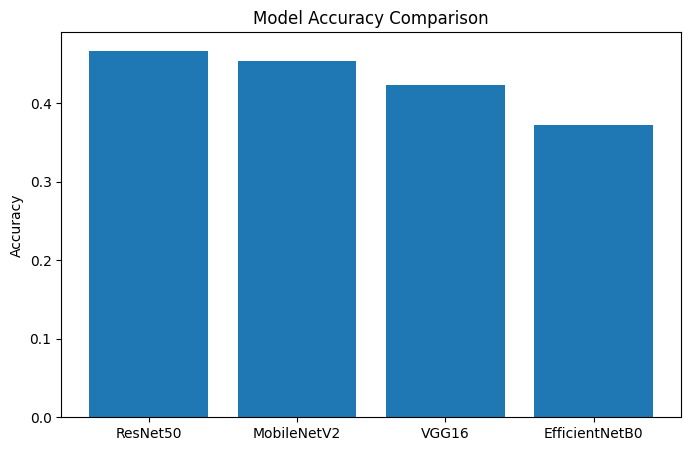

In [16]:
plt.figure(figsize=(8, 5))

plt.bar(
    results_df["Model"],
    results_df["Accuracy"]
)

plt.title("Model Accuracy Comparison")
plt.ylabel("Accuracy")
plt.show()

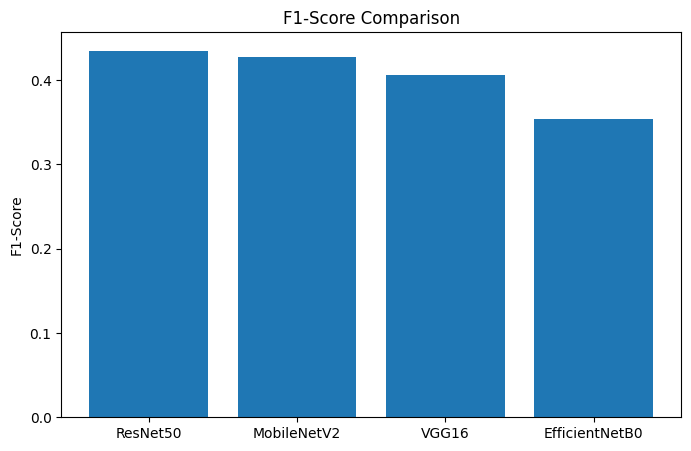

In [17]:
plt.figure(figsize=(8, 5))

plt.bar(
    results_df["Model"],
    results_df["F1-Score"]
)

plt.title("F1-Score Comparison")
plt.ylabel("F1-Score")
plt.show()

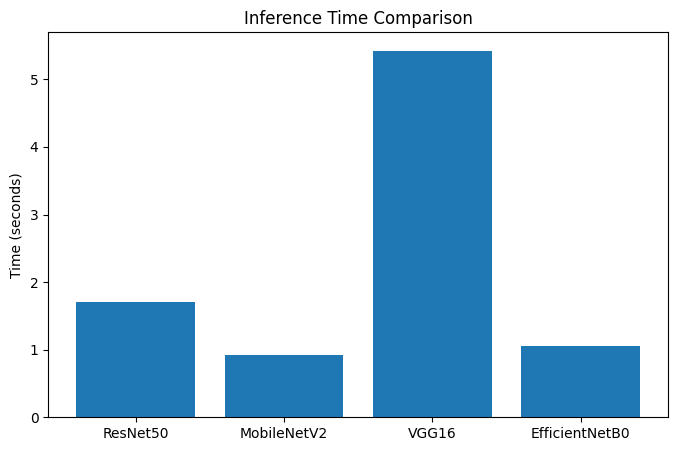

In [18]:
plt.figure(figsize=(8, 5))

plt.bar(
    results_df["Model"],
    results_df["Inference Time (s)"]
)

plt.title("Inference Time Comparison")
plt.ylabel("Time (seconds)")
plt.show()

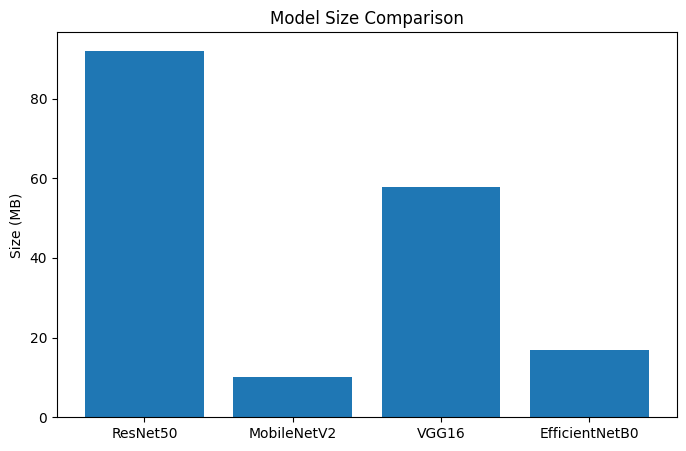

In [19]:
plt.figure(figsize=(8, 5))

plt.bar(
    results_df["Model"],
    results_df["Model Size (MB)"]
)

plt.title("Model Size Comparison")
plt.ylabel("Size (MB)")
plt.show()

In [20]:
best_model = results_df.iloc[0]

print("Best Model Selected")
print(best_model)

Best Model Selected
Model                  ResNet50
Accuracy               0.466667
Precision              0.453929
Recall                 0.466667
F1-Score               0.434925
Top-5 Accuracy         0.782051
Inference Time (s)     1.698811
Model Size (MB)       92.041015
Name: 1, dtype: object
